# 🕰️ Modelo com Defasagem Temporal — Corrigindo o Vazamento de Dados

Este notebook é um **complemento** ao `03_modelo_random_forest.ipynb`.

No notebook 03, o Random Forest atinge 98,3% de acurácia usando `media_portugues` e
`proporcao_aluno_nivel_*` do **mesmo ano** que está tentando prever — ou seja, o modelo
usa pedaços do próprio resultado da prova de 2024 pra "prever" o resultado de 2024. Isso
não é vazamento sutil: correlação de 0,927 entre `media_portugues` e `taxa_alfabetizacao`,
e de 0,985 somando `proporcao_aluno_nivel_5` a `_8` (ver seção 2 abaixo).

Aqui treinamos a versão **honesta**: só entram features do ano anterior (2023) pra prever
o resultado do ano seguinte (2024) — a chamada *defasagem temporal*. É o cenário que faz
sentido pra aplicação real do projeto: um gestor público só pode agir a tempo se souber do
risco **antes** do resultado da prova sair.

## Estrutura do notebook
1. Carregamento dos dados (Gold)
2. Recapitulação rápida do vazamento (mesmo ano)
3. Preparação: 1 linha por (município, ano) — resolvendo a duplicidade Estadual/Privada
4. Construção das features defasadas (LAG) com DuckDB
5. Divisão treino/teste e pipeline
6. Treinamento do Modelo D
7. Avaliação do modelo
8. Feature Importance
9. Comparação final: Modelo A (mesmo ano) vs. Modelo D (defasado)
10. Conclusões e recomendações para o time


## 1. Carregamento dos dados (Gold)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5.5)
plt.rcParams['font.size'] = 11

# Carrega o dataset Gold gerado pela Gabriela (mesmo caminho do notebook 03)
GOLD_PATH = Path('../data/gold/gold_indicador_municipio.parquet')
df = pd.read_parquet(GOLD_PATH)

print(f'Dataset carregado: {df.shape[0]} registros, {df.shape[1]} colunas')
df[['id_municipio', 'ano', 'rede_label', 'taxa_alfabetizacao', 'media_portugues']].head()


Dataset carregado: 15238 registros, 30 colunas


,id_municipio,ano,rede_label,taxa_alfabetizacao,media_portugues
0,1100031,2023,Estadual,69.10,767.8763
1,1100072,2023,Estadual,58.20,747.8918
2,1100189,2023,Privada,69.73,762.4062
3,1101609,2023,Estadual,50.70,745.6802
4,1101807,2023,Estadual,55.69,752.3724


## 2. Recapitulação rápida do vazamento (mesmo ano)

Antes de partir pra correção, vale confirmar por que o Modelo A do notebook 03 tem
performance tão alta. Duas checagens simples de correlação já explicam a maior parte:

In [ ]:
import duckdb

# 2.1 — media_portugues é quase o próprio target (mesma edição da prova)
corr_media = df[['media_portugues', 'taxa_alfabetizacao']].corr().iloc[0, 1]
print(f'Correlação media_portugues x taxa_alfabetizacao: {corr_media:.3f}')

# 2.2 — a soma das proporções de alunos nos níveis 5 a 8 reconstrói quase perfeitamente o target
niveis_cols = [c for c in df.columns if c.startswith('proporcao_aluno_nivel_')]
sub = df.dropna(subset=niveis_cols + ['taxa_alfabetizacao'])
soma_niveis_5_8 = sub[[f'proporcao_aluno_nivel_{n}' for n in range(5, 9)]].sum(axis=1)
corr_niveis = np.corrcoef(soma_niveis_5_8, sub['taxa_alfabetizacao'])[0, 1]
mae_niveis = (soma_niveis_5_8 - sub['taxa_alfabetizacao']).abs().mean()
print(f'Correlação soma(nível 5..8) x taxa_alfabetizacao: {corr_niveis:.3f}  (erro médio: {mae_niveis:.1f} p.p.)')

# 2.3 — as metas (2024..2030) embutem a trajetória histórica do próprio município
corr_meta = df[['taxa_meta_base', 'taxa_alfabetizacao']].corr().iloc[0, 1]
print(f'Correlação taxa_meta_base x taxa_alfabetizacao: {corr_meta:.3f}')

print()
print('Conclusão: essas três colunas (ou grupos de colunas) são versões diretas ou indiretas')
print('do próprio resultado do ano — não características independentes do município.')
print('Detalhe completo da comparação Modelo A / B / C está no relatório da apresentação.')


Correlação media_portugues x taxa_alfabetizacao: 0.926
Correlação soma(nível 5..8) x taxa_alfabetizacao: 0.983  (erro médio: 5.9 p.p.)
Correlação taxa_meta_base x taxa_alfabetizacao: 0.924

Conclusão: essas três colunas (ou grupos de colunas) são versões diretas ou indiretas
do próprio resultado do ano — não características independentes do município.
Detalhe completo da comparação Modelo A / B / C está no relatório da apresentação.


## 3. Preparação: 1 linha por (município, ano)

O dataset tem uma duplicidade conhecida: em ~80% dos casos, os valores de "Estadual"
(`rede` = 3) e "Privada" (`rede` = 5) são idênticos na fonte bruta — sinal de duplicação
de origem. O notebook 01 remove parte dessas duplicatas, mas **só quando `taxa_alfabetizacao`
e `media_portugues` são idênticos entre as duas redes**. Quando os valores diferem (mesmo
que pouco), as duas linhas sobrevivem.

Isso é um problema pra nós agora: se um município aparece como "Estadual" em 2023 e
"Privada" em 2024 (ou tem as duas redes no mesmo ano), um `LAG` ingênuo por
`(id_municipio, rede_label)` erra o pareamento — ou não encontra o ano anterior, ou pareia
anos errados. Então agregamos para 1 linha por (município, ano) antes de calcular a defasagem.

In [ ]:
# Quantificando o problema antes de corrigir
n_redes_trocando = duckdb.sql("""
    SELECT COUNT(*) AS municipios_com_rede_trocando
    FROM (
        SELECT id_municipio, COUNT(DISTINCT rede_label) AS n_redes_distintas
        FROM df
        WHERE rede_label IN ('Estadual', 'Privada')
        GROUP BY id_municipio
        HAVING COUNT(DISTINCT rede_label) = 2
    )
""").df()
print('Municípios com o rótulo de rede trocando entre Estadual/Privada de um ano pro outro:')
print(n_redes_trocando)

n_duplicado_mesmo_ano = duckdb.sql("""
    SELECT n_linhas, COUNT(*) AS n_casos
    FROM (
        SELECT id_municipio, ano, COUNT(*) AS n_linhas
        FROM df
        WHERE rede_label IN ('Estadual', 'Privada')
        GROUP BY id_municipio, ano
    )
    GROUP BY n_linhas ORDER BY n_linhas
""").df()
print()
print('(município, ano) com mais de 1 linha entre Estadual/Privada:')
print(n_duplicado_mesmo_ano)


Municípios com o rótulo de rede trocando entre Estadual/Privada de um ano pro outro:
   municipios_com_rede_trocando
0                          3244

(município, ano) com mais de 1 linha entre Estadual/Privada:
   n_linhas  n_casos
0         1     8740
1         2     2101


In [ ]:
# Correção: agrega Estadual/Privada num único valor por (município, ano)
um_por_ano = duckdb.sql("""
    SELECT id_municipio, ano,
           AVG(taxa_alfabetizacao) AS taxa_alfabetizacao,
           AVG(media_portugues)    AS media_portugues,
           AVG(percentual_participacao) AS percentual_participacao,
           AVG(meta_2024) AS meta_2024, AVG(meta_2025) AS meta_2025, AVG(meta_2026) AS meta_2026,
           AVG(meta_2027) AS meta_2027, AVG(meta_2028) AS meta_2028, AVG(meta_2029) AS meta_2029,
           AVG(meta_2030) AS meta_2030
    FROM df
    WHERE rede_label IN ('Estadual', 'Privada')
    GROUP BY id_municipio, ano
""").df()

print(f'Shape após agregação (1 linha por município-ano): {um_por_ano.shape}')
um_por_ano.head()


Shape após agregação (1 linha por município-ano): (10841, 12)


,id_municipio,ano,taxa_alfabetizacao,media_portugues,percentual_participacao,meta_2024,meta_2025,meta_2026,meta_2027,meta_2028,meta_2029,meta_2030
0,1100031,2023,69.100,767.8763,90.48,70.85,72.53,74.15,75.71,77.21,78.64,80.0
1,1100072,2023,58.200,747.8918,92.25,61.82,65.31,68.64,71.79,74.74,77.48,80.0
2,1100189,2023,69.730,762.4062,90.35,71.37,72.95,74.48,75.95,77.36,78.71,80.0
3,1101807,2023,55.690,752.3724,83.15,59.72,63.63,67.37,70.89,74.18,77.22,80.0
4,1302900,2023,55.605,733.3974,78.48,57.61,61.93,66.08,69.99,73.62,76.97,80.0


## 4. Construção das features defasadas (LAG) com DuckDB

Agora sim: para cada município, trazemos os valores de **2023** para a mesma linha do
**2024**, usando a função de janela `LAG`. O target continua sendo o resultado de 2024
(`taxa_alfabetizacao >= 50`), mas todas as features vêm do ano anterior.

In [ ]:
lagged = duckdb.sql("""
    SELECT
        id_municipio,
        ano,
        taxa_alfabetizacao AS taxa_alfabetizacao_2024,   -- guardado só pra conferência, não entra no X
        (taxa_alfabetizacao >= 50)::INT AS target,
        LAG(media_portugues)          OVER w AS media_portugues_ant,
        LAG(taxa_alfabetizacao)       OVER w AS taxa_alfabetizacao_ant,
        LAG(percentual_participacao)  OVER w AS percentual_participacao_ant,
        meta_2024, meta_2025, meta_2026, meta_2027, meta_2028, meta_2029, meta_2030
        -- as metas ficam sem defasagem: são valores definidos ANTES do resultado do ano
        -- vigente (são a meta oficial do programa, não uma consequência do resultado)
    FROM um_por_ano
    WINDOW w AS (PARTITION BY id_municipio ORDER BY ano)
    QUALIFY taxa_alfabetizacao_ant IS NOT NULL AND ano = 2024
""").df()

print(f'Shape da base defasada (features de 2023 -> target de 2024): {lagged.shape}')
lagged[['id_municipio', 'taxa_alfabetizacao_2024', 'taxa_alfabetizacao_ant', 'media_portugues_ant']].head()


Shape da base defasada (features de 2023 -> target de 2024): (5312, 14)


,id_municipio,taxa_alfabetizacao_2024,taxa_alfabetizacao_ant,media_portugues_ant
0,1101476,57.630,86.090,787.0699
1,1300144,56.710,59.680,742.1646
2,1300706,47.195,57.055,739.6557
3,1302207,45.830,44.365,727.1586
4,1303304,52.055,81.065,757.7478


In [ ]:
# Confirma o número de pares e a correlação "honesta" (passado do próprio município -> futuro)
corr_check = duckdb.sql("""
    SELECT count(*) AS n_pares, corr(taxa_alfabetizacao_ant, taxa_alfabetizacao_2024) AS correlacao
    FROM lagged
""").df()
print(corr_check)
print()
print('Esse ~0,62 é o sinal preditivo real de persistência temporal — bem mais modesto que')
print('os 0,92-0,98 "falsos" de features do mesmo ano, mas é um sinal genuíno.')


   n_pares  correlacao
0     5312    0.624508

Esse ~0,62 é o sinal preditivo real de persistência temporal — bem mais modesto que
os 0,92-0,98 "falsos" de features do mesmo ano, mas é um sinal genuíno.


## 5. Divisão treino/teste e pipeline

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

FEATURE_COLS = [
    'media_portugues_ant', 'taxa_alfabetizacao_ant', 'percentual_participacao_ant',
    'meta_2024', 'meta_2025', 'meta_2026', 'meta_2027', 'meta_2028', 'meta_2029', 'meta_2030',
]

X = lagged[FEATURE_COLS].copy()
y = lagged['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} municípios ({X_train.shape[0]/len(X):.0%})')
print(f'Teste:  {X_test.shape[0]} municípios ({X_test.shape[0]/len(X):.0%})')
print(f'Balanceamento no treino: {y_train.mean():.1%} positivos')
print(f'Balanceamento no teste:  {y_test.mean():.1%} positivos')

# Mesmo pipeline de pré-processamento do notebook 03 (só numéricas aqui: sem rede/serie,
# já que agregamos por município-ano)
preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), FEATURE_COLS),
])

pipeline_d = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1
    )),
])
print()
print('Pipeline (Modelo D) criado com sucesso!')


Treino: 4249 municípios (80%)
Teste:  1063 municípios (20%)
Balanceamento no treino: 74.7% positivos
Balanceamento no teste:  74.7% positivos

Pipeline (Modelo D) criado com sucesso!


## 6. Treinamento do Modelo D

In [ ]:
import time

inicio = time.time()
pipeline_d.fit(X_train, y_train)
duracao = round(time.time() - inicio, 2)
print(f'Modelo D treinado em {duracao}s!')


Modelo D treinado em 0.7s!


## 7. Avaliação do modelo

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc,
)

y_pred = pipeline_d.predict(X_test)
y_proba = pipeline_d.predict_proba(X_test)[:, 1]

acc_d  = accuracy_score(y_test, y_pred)
prec_d = precision_score(y_test, y_pred)
rec_d  = recall_score(y_test, y_pred)
f1_d   = f1_score(y_test, y_pred)
fpr_d, tpr_d, _ = roc_curve(y_test, y_proba)
auc_d = auc(fpr_d, tpr_d)
baseline = max(y_test.mean(), 1 - y_test.mean())

print('=' * 55)
print('MÉTRICAS DO MODELO D — CONJUNTO DE TESTE (defasado)')
print('=' * 55)
print(f'  Accuracy:  {acc_d:.4f} ({acc_d:.1%})')
print(f'  Precision: {prec_d:.4f} ({prec_d:.1%})')
print(f'  Recall:    {rec_d:.4f} ({rec_d:.1%})')
print(f'  F1-Score:  {f1_d:.4f} ({f1_d:.1%})')
print(f'  AUC-ROC:   {auc_d:.4f}')
print(f'  Baseline (classe majoritária): {baseline:.1%}')
print('=' * 55)
print()
print(classification_report(y_test, y_pred, target_names=['Não Alfabetizado', 'Alfabetizado']))


MÉTRICAS DO MODELO D — CONJUNTO DE TESTE (defasado)
  Accuracy:  0.8363 (83.6%)
  Precision: 0.8563 (85.6%)
  Recall:    0.9383 (93.8%)
  F1-Score:  0.8954 (89.5%)
  AUC-ROC:   0.8400
  Baseline (classe majoritária): 74.7%

                  precision    recall  f1-score   support

Não Alfabetizado       0.75      0.54      0.62       269
    Alfabetizado       0.86      0.94      0.90       794

        accuracy                           0.84      1063
       macro avg       0.80      0.74      0.76      1063
    weighted avg       0.83      0.84      0.83      1063



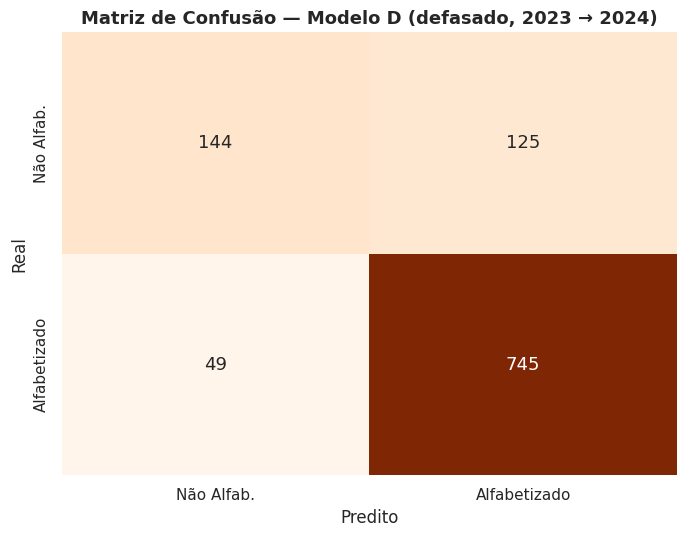

In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Não Alfab.', 'Alfabetizado'],
            yticklabels=['Não Alfab.', 'Alfabetizado'], ax=ax, cbar=False, annot_kws={'size': 13})
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Modelo D (defasado, 2023 → 2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


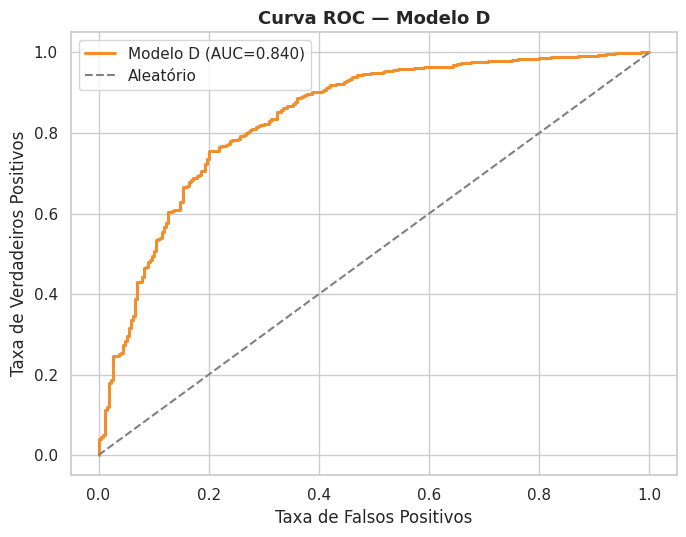

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(fpr_d, tpr_d, color='#f28e2b', lw=2.2, label=f'Modelo D (AUC={auc_d:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatório')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — Modelo D', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Feature Importance

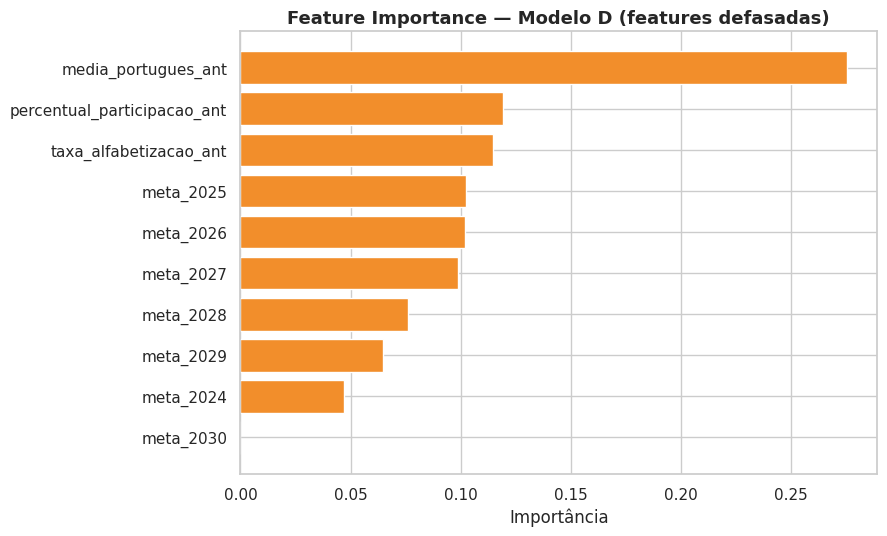

                    feature  importance
        media_portugues_ant    0.275426
percentual_participacao_ant    0.119136
     taxa_alfabetizacao_ant    0.114616
                  meta_2025    0.102557
                  meta_2026    0.102059
                  meta_2027    0.098741
                  meta_2028    0.075903
                  meta_2029    0.064553
                  meta_2024    0.047009
                  meta_2030    0.000000


In [ ]:
rf_d = pipeline_d.named_steps['model']
fi_d = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf_d.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(fi_d['feature'][::-1], fi_d['importance'][::-1], color='#f28e2b')
ax.set_xlabel('Importância')
ax.set_title('Feature Importance — Modelo D (features defasadas)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(fi_d.to_string(index=False))


## 9. Comparação final: Modelo A (mesmo ano) vs. Modelo D (defasado)

Para comparar de forma justa, os números do Modelo A abaixo são os mesmos reportados no
notebook 03 / relatório da apresentação (mesmos hiperparâmetros, mesma seed).

In [ ]:
comparacao = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC', 'Nº de municípios (teste)'],
    'Modelo A (mesmo ano, com vazamento)': ['98,3%', '99,0%', '98,6%', '98,8%', '0,997', '3.048'],
    'Modelo D (defasado, honesto)': [
        f'{acc_d:.1%}', f'{prec_d:.1%}', f'{rec_d:.1%}', f'{f1_d:.1%}', f'{auc_d:.3f}', f'{len(X_test)}'
    ],
})
comparacao


,Métrica,"Modelo A (mesmo ano, com vazamento)","Modelo D (defasado, honesto)"
0,Accuracy,"98,3%",83.6%
1,Precision,"99,0%",85.6%
2,Recall,"98,6%",93.8%
3,F1-score,"98,8%",89.5%
4,AUC-ROC,"0,997",0.840
5,Nº de municípios (teste),3.048,1063


## 10. Conclusões e recomendações para o time

**O que mudou:** o Modelo D só usa informação que existia *antes* do resultado que está
tentando prever (dados de 2023 para prever 2024). Isso é o que torna o modelo utilizável
na prática — um gestor público pode agir com esse resultado em mãos, o que não faz sentido
com o Modelo A (que só "acerta" depois que a prova já saiu).

**O que perdemos:** a base caiu de 15.238 linhas para 5.312 pares (só municípios com os
dois anos disponíveis), e a acurácia caiu dos 98,3% "de mentirinha" do Modelo A para um
número mais modesto — mas ainda claramente acima do baseline ingênuo, e agora genuíno.

**Limitações a documentar:**
- O dataset só tem 2 anos (2023 e 2024), então esse é um único "salto" no tempo — não dá
  pra validar generalização pra vários anos futuros, só pra este.
- A deduplicação Estadual/Privada do notebook 01 precisa de um critério explícito (hoje
  só remove duplicatas exatas; 2.101 casos de (município, ano) ficam com as duas redes
  sobrevivendo, e agregamos por média aqui — o time deve validar se essa é a melhor forma).

**Recomendação:** levar essa comparação (seção 9) pro time e decidir juntos se o modelo
final da Fase 3 será o A (mesmo ano, mais "bonito" nos números, mas sem uso prático real)
ou o D (defasado, números mais modestos, mas genuinamente aplicável) — ou reportar os dois,
com essa reflexão, como diferencial de rigor metodológico na entrega.
